# Example notebook

In this tutorial, we go through the basic functionalities of `mulink`.  

`mulink` extends the namespace of `mudata`. When you import mulink, your mudata objects will automatically get obtain an additional `.link` attribute, which provides you access to `mulink`'s extended functionalities like 

- querying
- [More to come soon]

In [ ]:
import mulink
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
import pandas as pd

## Simulate data

Let's simulate a mulink-compatible mudata object with 3 modalities. Here, we assume a hierarchical relationship between the individual modalities, meaning that features of modality 0 only map to successive layers (modality 1 and 2) and so on. 

More formally, this means that the feature graph does not contain any [_cycles_](../RFC.md#Directed-Acyclic-Graph). 

In [51]:
mdata = mulink.simulate.hierarchical_mudata(n_mod=3)
mdata

/Users/lucas-diedrich/mamba/envs/mulink/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/mulink/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 5 × 14
  varp:	'feature_mapping'
  3 modalities
    mod0:	5 × 2
    mod1:	5 × 4
    mod2:	5 × 8

## Representing relationships between features
The relationship between features is formalized as [directed acyclic graph](../RFC.md#Directed-Acyclic-Graph). This means that if two features A and B are related, feature A _points_ to feature B via a directed edge in the graph. 

More specifically, we store this relationship in form the graph's [_adjacency matrix_](../rfc.md#Adjacency-Matrix) in the `mudata.MuData.varp` attribute. Per default, the name of the adjacency matrix is `feature mapping`. We can visualize this adjacency matrix. Each green field indicates a directed connection/edge between two features from row mapping to column

/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_51626/2595830685.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(mdata.var_names, rotation=0, ha="right")
/var/folders/py/838_q5nd6594y27wbrpkhl3h0000gn/T/ipykernel_51626/2595830685.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mdata.var_names, rotation=45, ha="right")


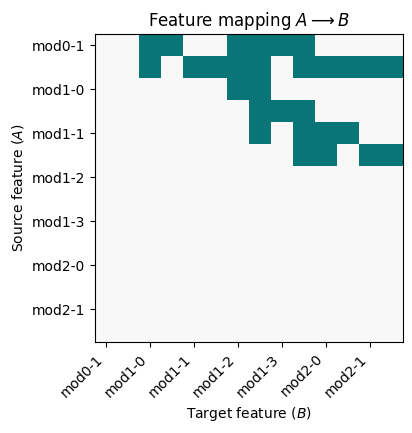

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.imshow(mdata.varp["feature_mapping"].toarray(), cmap=mpl.colors.ListedColormap(["#f8f8f8", "#097577"]))
ax.set(title="Feature mapping $A \\longrightarrow B$", xlabel="Target feature ($B$)", ylabel="Source feature ($A$)")
ax.set_yticklabels(mdata.var_names, rotation=0, ha="right")
ax.set_xticklabels(mdata.var_names, rotation=45, ha="right")
plt.show()

This is equivalent to the following directed graph.

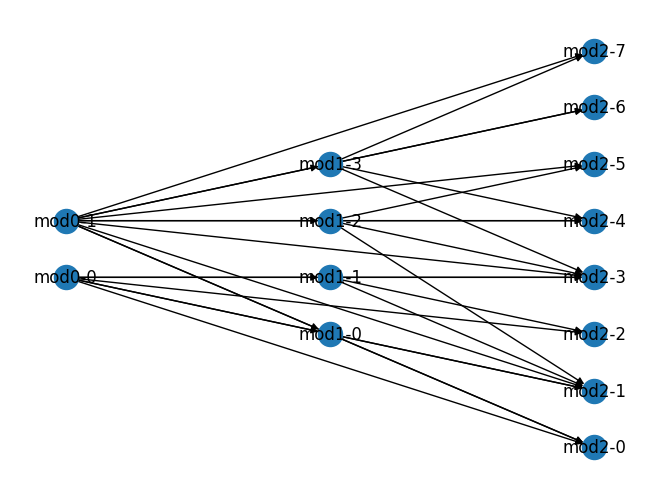

In [60]:
# Construct graph
dag = nx.from_pandas_adjacency(
    pd.DataFrame.sparse.from_spmatrix(mdata.varp["feature_mapping"], index=mdata.var_names, columns=mdata.var_names),
    create_using=nx.DiGraph,
)

# Plot
pos = nx.layout.multipartite_layout(dag, subset_key={key: mdata.mod[key].var_names for key in mdata.mod.keys()})
nx.draw(dag, pos=pos, with_labels=True)

## Querying

We can use this graph to find related features. For example, we can find all features that downstream to feature 0 in modality 0 (`mod0-0`)

In [62]:
mdata.link.query_descendants(features=["mod0-0"])

View of MuData object with n_obs × n_vars = 5 × 7
  varp:	'feature_mapping'
  3 modalities
    mod0:	5 × 1
    mod1:	5 × 2
    mod2:	5 × 4

In [63]:
mdata.link.query_descendants(features=["mod0-0"], include_self=False)

View of MuData object with n_obs × n_vars = 5 × 6
  varp:	'feature_mapping'
  3 modalities
    mod0:	5 × 0
    mod1:	5 × 2
    mod2:	5 × 4

Equivalently, we can find all ancestors of a specific feature. 

In [65]:
mdata.link.query_ancestors(features=["mod2-1"])

View of MuData object with n_obs × n_vars = 5 × 6
  varp:	'feature_mapping'
  3 modalities
    mod0:	5 × 2
    mod1:	5 × 3
    mod2:	5 × 1

To get a specific modality level, you can use the standard `mudata` query:

In [67]:
subset = mdata.link.query_descendants(features=["mod0-0"])
subset.mod["mod0"].copy()

AnnData object with n_obs × n_vars = 5 × 1